# Investigate simulations with individual soil column per pft  

Inlcuding regridding

(c) Inne Vanderkelen - October 2023

## 1. Settings

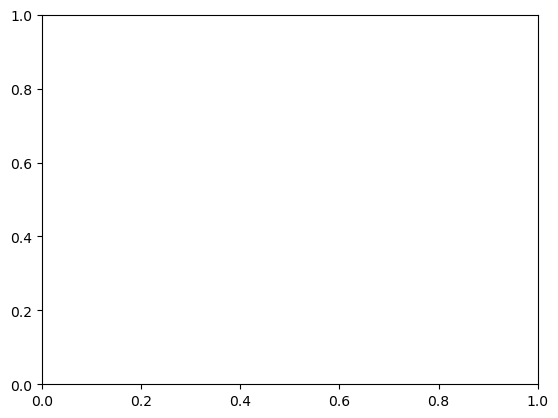

In [3]:
# laod modules 
import xarray as xr
import matplotlib.pyplot as plt
import os
import regionmask 
import pandas as pd
from matplotlib import cm
import geopandas as gpd
from matplotlib import colors

# import own utils module
from iv_utils_daint import *
from ctsm_py.utils import  * #info on ctsm utils: https://github.com/NCAR/ctsm_python_gallery 

# do plotting settings
set_plot_param()

# ignore all runtime warnings
warnings.filterwarnings('ignore')

In [4]:
# directory settings

# set directories
outdir = '/scratch/snx3000/ivanderk/'
outdir = '/project/s1207/ivanderk/scratch/'

figdir = '/users/ivanderk/notebooks_4p1000/figures/'

outdir = '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/innev/4p1000/'
figdir = '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/innev/4p1000/Vanderkelen_etal_2025_BG/figures/'
datadir = '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/innev/4p1000/Vanderkelen_etal_2025_data_topublish/'

# Define directory where processing is done 
procdir =  outdir + 'processing_4p1000/' 

# go to processing directory 
os.chdir(procdir)

In [5]:
# case settings

# define scenario
scenarios = ['high', '4p1000', 'medium']
scenario = '4p1000'
# case settings
case_ctl = 'IHistClm51Sp.hcru_hcru_mt13.pftsoilcol.CTL.spunup5'
case_scen = 'IHistClm51Sp.hcru_hcru_mt13.pftsoilcol.'+scenario+'.spunup5'

case   = case_ctl
block  = 'lnd' 
stream = 'h1' 


# discard 2004 until 2008 as spin up years
start_year, end_year = 1995, 2014 

time_slice = slice(str(start_year)+"-01-01", str(end_year)+"-12-01")

## settings for plotting
ds_ctl =  load_case_ctl(['H2OSOI'])

# get mask and region ids
exclude_ids = np.array([0,1,2,16,28,29,30,31])
mask_regions = regionmask.defined_regions.ar6.land.mask(ds_ctl['H2OSOI'])

region_ids = np.arange(0,44)
region_ids = np.delete(region_ids, exclude_ids)

regions_sand_clay = [6, 7, 10, 11, 12, 14, 19, 21, 22, 23, 24, 26, 37, 38, 39, 41]

plotting_depth = 2 # m 8
figsize = (17,38)

# get pfts modelled - bare soil, grassland and crop pfts
pft_list_crops = [15,16]

### Load auxiliary data (soil levels, input dataset, wilting point etc) 

In [ ]:
# info on soil levels
# manually get soil level info from CLM
levsoi_thickness, levsoi_depth, levgrnd_thickness , levgrnd_depth = get_soildepths()

# get info on soil levels
levsoi = ds_ctl['levsoi'].values
levgrnd = ds_ctl['levgrnd'].values # all soil layers (deepest 5 layers are for thermodynamical calculations)

# input data
# define variables to load from input dataset
input_variables = ['ORGANIC','PFTDATA_MASK','PCT_SAND','PCT_CLAY']
case_ctl_forinputdata = 'IHistClm51Sp.hcru_hcru_mt13.pftsoilcol.CTL.spunup5'

# load inputdata
ds_input, ds_input_scen, landmask = load_inputdata(scenario, input_variables, case_ctl_forinputdata)
organic_mask = (ds_input['ORGANIC'][0,:,:]<=130)
# get texture details
pct_sand = ds_input['PCT_SAND']
pct_clay = ds_input['PCT_CLAY']
da_organic = ds_input['ORGANIC']

# wilting point
# load precalculated wilting point datasets
da_wilting_h2osoi, da_wilting_h2osoi_scen = load_wilting_h2osoi(scenario) 
# load precalculated field capacity

da_fc_h2osoi, da_fc_h2osoi_scen = load_fc_h2osoi(scenario) 

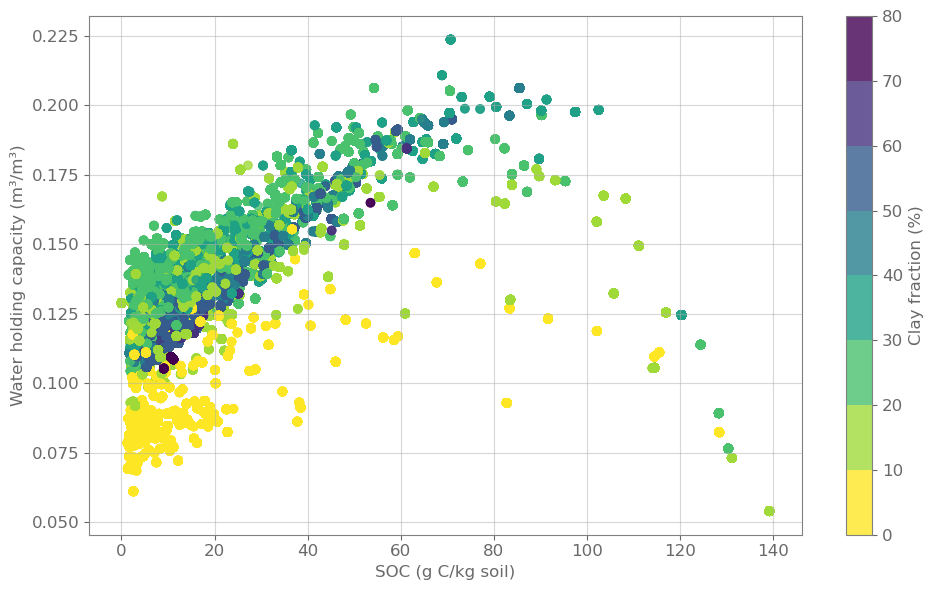

In [24]:
da_awc = da_fc_h2osoi - da_wilting_h2osoi

fig, ax = plt.subplots(figsize=(10,6))
ax.grid(True, alpha=0.5)

# define discrete bins (example: 0-10, 10-20, ..., 90-100)
levels = np.arange(0, 90, 10)   # boundaries, last value > max bin
n_bins = len(levels) - 1

# create a categorical colormap with n_bins colors
cmap = plt.get_cmap('viridis_r', n_bins)   # returns a ListedColormap with n_bins entries

# let BoundaryNorm map values to bins (use the same 'levels' boundaries)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=cmap.N, clip=True)

sc = ax.scatter( da_organic.where(organic_mask).values.flatten(),da_awc.where(organic_mask).values.flatten(), c=ds_input["PCT_CLAY"].where(organic_mask), cmap=cmap, norm=norm,  alpha=0.8)
cbar = fig.colorbar(sc, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
cbar.set_label('Clay fraction (%)')

ax.set_xlabel('SOC (g C/kg soil)')
ax.set_ylabel('Water holding capacity (m³/m³)')
#ax.set_title('Water holding capacity ($\Theta_{fc} - \Theta_{wp}$) with increasind', loc='right');

fig.tight_layout()
fig.savefig(figdir+'whc_to_soc_sensitivity.png', bbox_inches='tight')


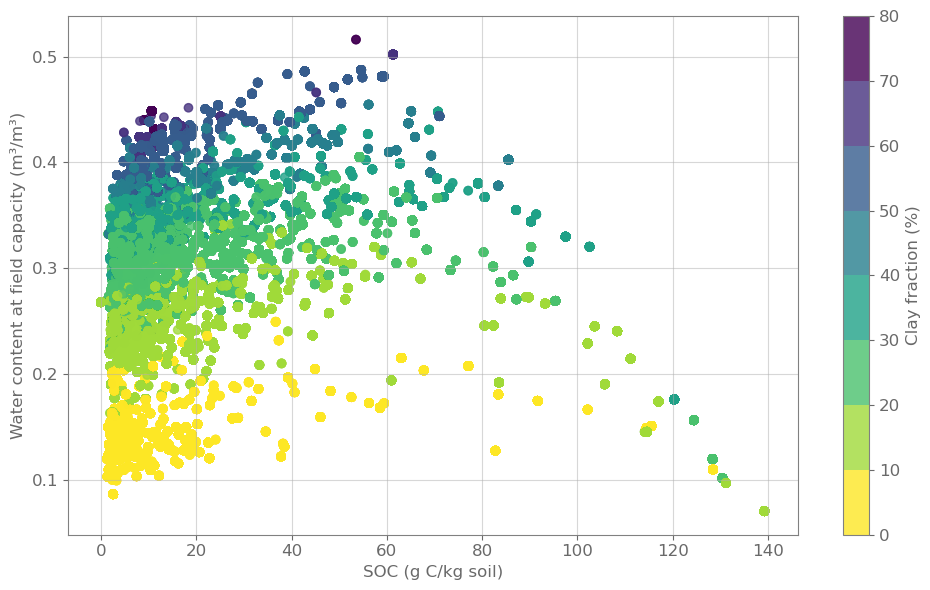

In [23]:
da_awc = da_fc_h2osoi - da_wilting_h2osoi

fig, ax = plt.subplots(figsize=(10,6))
ax.grid(True, alpha=0.5)

# define discrete bins (example: 0-10, 10-20, ..., 90-100)
levels = np.arange(0, 90, 10)   # boundaries, last value > max bin
n_bins = len(levels) - 1

# create a categorical colormap with n_bins colors
cmap = plt.get_cmap('viridis_r', n_bins)   # returns a ListedColormap with n_bins entries

# let BoundaryNorm map values to bins (use the same 'levels' boundaries)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=cmap.N, clip=True)

sc = ax.scatter( da_organic.where(organic_mask).values.flatten(),da_fc_h2osoi.where(organic_mask).values.flatten(), c=ds_input["PCT_CLAY"].where(organic_mask), cmap=cmap, norm=norm,  alpha=0.8)
cbar = fig.colorbar(sc, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
cbar.set_label('Clay fraction (%)')

ax.set_xlabel('SOC (g C/kg soil)')
ax.set_ylabel('Water content at field capacity (m³/m³)')
#ax.set_title('Water holding capacity ($\Theta_{fc} - \Theta_{wp}$) with increasind', loc='right');

fig.tight_layout()
fig.savefig(figdir+'fc_to_soc_sensitivity.png', bbox_inches='tight')


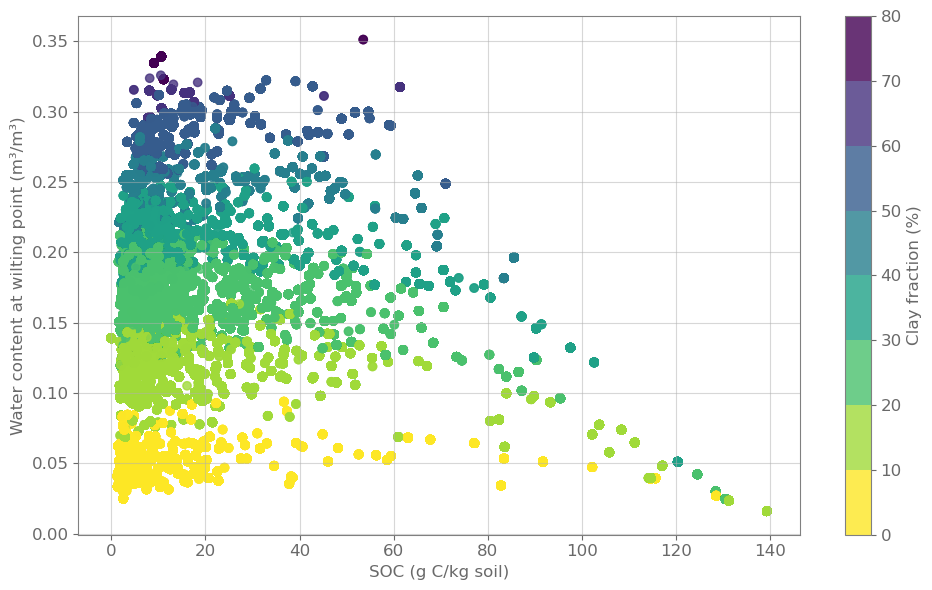

In [22]:
da_awc = da_fc_h2osoi - da_wilting_h2osoi

fig, ax = plt.subplots(figsize=(10,6))
ax.grid(True, alpha=0.5)

# define discrete bins (example: 0-10, 10-20, ..., 90-100)
levels = np.arange(0, 90, 10)   # boundaries, last value > max bin
n_bins = len(levels) - 1

# create a categorical colormap with n_bins colors
cmap = plt.get_cmap('viridis_r', n_bins)   # returns a ListedColormap with n_bins entries

# let BoundaryNorm map values to bins (use the same 'levels' boundaries)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=cmap.N, clip=True)

sc = ax.scatter( da_organic.where(organic_mask).values.flatten(),da_wilting_h2osoi.where(organic_mask).values.flatten(), c=ds_input["PCT_CLAY"].where(organic_mask), cmap=cmap, norm=norm,  alpha=0.8)
cbar = fig.colorbar(sc, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
cbar.set_label('Clay fraction (%)')

ax.set_xlabel('SOC (g C/kg soil)')
ax.set_ylabel('Water content at wilting point (m³/m³)')
#ax.set_title('Water holding capacity ($\Theta_{fc} - \Theta_{wp}$) with increasind', loc='right');

fig.tight_layout()
fig.savefig(figdir+'wp_to_soc_sensitivity.png', bbox_inches='tight')


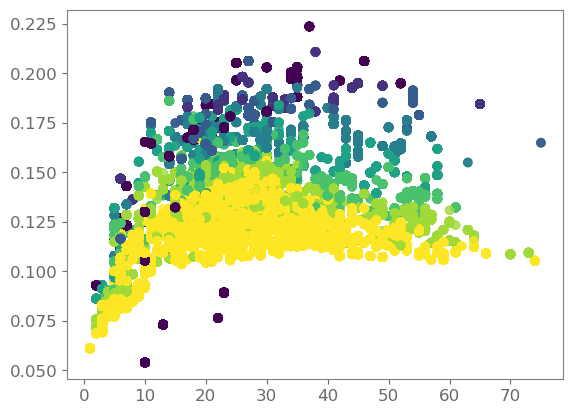

In [26]:
plt.scatter( ds_input["PCT_CLAY"].values.flatten(),da_awc.where(organic_mask).values.flatten(), c=da_organic.where(organic_mask).where(organic_mask), cmap=cmap, norm=norm,  alpha=0.8)


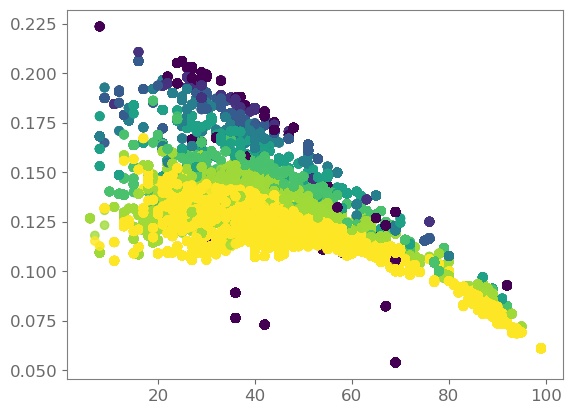

In [27]:
plt.scatter( ds_input["PCT_SAND"].values.flatten(),da_awc.where(organic_mask).values.flatten(), c=da_organic.where(organic_mask).where(organic_mask), cmap=cmap, norm=norm,  alpha=0.8)
